# Ovrlpy applied to vizgen receptor data map



In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
from matplotlib_scalebar.scalebar import ScaleBar

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys

import matplotlib

sys.path.append("../..")

from utils import CM, FONT, plot_doublet, save_kwargs

matplotlib.rc("font", **FONT)

In [4]:
boundaries_path = "../cell_boundaries.parquet"
coordinate_path = "../detected_transcripts.parquet"

In [5]:
import pickle

with open("../merscope_brain.pickle", "rb") as file:
    brain = pickle.load(file)

coordinate_df = brain.transcripts

signal_integrity = brain.integrity_map
signal_strength = brain.signal_map

In [6]:
import geopandas as gpd
from shapely import union_all

boundary_df = (
    gpd.read_parquet(boundaries_path, columns=["EntityID", "Geometry"])
    .groupby("EntityID")
    .aggregate({"Geometry": union_all})
    .set_geometry("Geometry")
)

In [7]:
from shapely import STRtree

tree = STRtree(boundary_df["Geometry"])
query = tree.query(boundary_df["Geometry"], predicate="intersects")

# get all pairs where i < j (to avoid having duplicates)
# pairs only intersect in bounding box
intersecting = query[:, query[0] < query[1]]

In [8]:
from rasterio.features import rasterize
from rasterio.transform import from_origin

intersection = [
    boundary_df["Geometry"].iat[i].intersection(boundary_df["Geometry"].iat[j])
    for i, j in zip(intersecting[0], intersecting[1])
]

# ensure same dimensions as the ovrlpy map
origin = ovrlpy.io.read_MERSCOPE(coordinate_path).select(("x", "y")).min()
transform = from_origin(origin["x"][0], origin["y"][0], 1, -1)

segmentation_doublets = rasterize(
    intersection,
    out_shape=signal_strength.shape,
    transform=transform,
    all_touched=True,
    dtype=int,
)
segmentation_doublets = segmentation_doublets.astype(bool)

In [9]:
# high confidence doublets
doublet_df = brain.detect_doublets(min_integrity=0.5, min_signal=3, integrity_sigma=2)

In [10]:
n_doublets = doublet_df.shape[0]
n_retrieved = segmentation_doublets[doublet_df["y"], doublet_df["x"]].sum()

print(f"# doublets: {n_doublets}")
print(f"# doublets also in segmentation: {n_retrieved}")
print(f"{n_retrieved / n_doublets * 100:.2f}% doublets retrieved")

# doublets: 810
# doublets also in segmentation: 69
8.52% doublets retrieved


In [11]:
from skimage.morphology import binary_dilation

n_retrieved = binary_dilation(
    segmentation_doublets, footprint=np.ones((3, 3), dtype=bool)
)[doublet_df["y"], doublet_df["x"]].sum()

print(f"# doublets: {n_doublets}")
print(f"# doublets also in segmentation (dilation by 1): {n_retrieved}")
print(f"{n_retrieved / n_doublets * 100:.2f}% doublets retrieved")

# doublets: 810
# doublets also in segmentation (dilation by 1): 123
15.19% doublets retrieved


In [12]:
low_vsi = signal_integrity < 0.5
strong_signal = signal_strength > 3

frac_doublet_lo_vsi = (
    segmentation_doublets[low_vsi & strong_signal].sum()
    / (low_vsi & strong_signal).sum()
)
frac_doublet_hi_vsi = (
    segmentation_doublets[~low_vsi & strong_signal].sum()
    / (~low_vsi & strong_signal).sum()
)
print(f"{frac_doublet_lo_vsi * 100:.2f}% of pixels are doublets in low VSI regions")
print(f"{frac_doublet_hi_vsi * 100:.2f}% of pixels are doublets in high VSI regions")

9.51% of pixels are doublets in low VSI regions
4.48% of pixels are doublets in high VSI regions


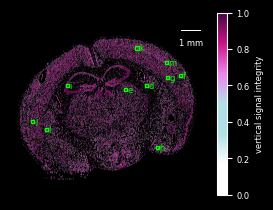

In [13]:
alphabet = "abcdefghijklmnopqrstuvwxyz"

fig = ovrlpy.plot_signal_integrity(
    brain,
    histogram=False,
    scalebar={"dx": 1, "units": "um", "frameon": False, "color": "w"},
    figsize=(8 * CM, 6 * CM),
)

ax = fig.axes[0]

ax.invert_yaxis()
ax.invert_xaxis()
ax.axis("off")


for i in range(10):
    x, y = doublet_df["x", "y"].row(i)
    ax.text(x - 100, y, alphabet[i + 3], fontsize=6, color="lime", va="center")
    ax.scatter(x, y, marker="s", s=5, edgecolors="lime", facecolors="None", lw=1)


fig.savefig("receptor_integrity.svg", **save_kwargs)

In [14]:
from shapely import box
from shapely.affinity import translate


def plot_outlines(gdf, x, y, window_size, ax):
    x_, _x = x - window_size, x + window_size
    y_, _y = y - window_size, y + window_size

    roi = box(x_, y_, _x, _y)
    gdf = gdf[gdf.intersects(roi)].copy()

    gdf["Geometry"] = gdf["Geometry"].apply(
        lambda geom: translate(geom, xoff=-x_, yoff=-y_)
    )

    for i, (_, cell) in enumerate(gdf.groupby("EntityID", observed=True)):
        for geom in cell.Geometry:
            ax.plot(*geom.exterior.xy, c=colors[i % len(colors)], lw=1)

In [15]:
# move boundaries into same space as ovrlpy analysis
boundary_df["Geometry"] = boundary_df["Geometry"].apply(
    lambda geom: translate(geom, xoff=-origin["x"][0], yoff=-origin["y"][0])
)

In [22]:
import colorcet as cc

colors = list(cc.glasbey)
# remove unsuitable colors
_ = colors.pop(15)
_ = colors.pop(6)

In [24]:
window_size = 40

scalebar = dict(
    dx=1, units="um", length_fraction=0.2, loc="lower left", frameon=False, color="w"
)

with plt.style.context("dark_background"):
    for i in range(10):
        x, y = doublet_df["x", "y"].row(i)

        fig = plot_doublet(
            brain,
            x,
            y,
            window_size=window_size,
            signal_threshold=2,
            figsize=(9 * CM, 2.8 * CM),
        )

        for j in range(4):
            fig.axes[j].collections[0].set_rasterized(True)

        plot_outlines(boundary_df, x, y, window_size, fig.axes[4])

        fig.axes[0].add_artist(ScaleBar(**scalebar))

        fig.savefig(f"receptor_doublet_{i + 1}_segments.svg", **save_kwargs)
        plt.close()